# 3. Data Quality Assessment <a id="3-data-quality" name="3-data-quality"></a>



In [ ]:
# Missing values analysis
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
quality_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct,
    "Present Count": len(df_raw) - missing,
    "Dtype": df_raw.dtypes
}).sort_values("Missing %", ascending=False)

print("DATA QUALITY REPORT:")
display(quality_df)


DATA QUALITY REPORT:


,Missing Count,Missing %,Present Count,Dtype
homepage,2919,53.07,2581,str
tagline,821,14.93,4679,str
writer,214,3.89,5286,str
production_companies_country,164,2.98,5336,str
production_companies_name,76,1.38,5424,str
imdb_id,34,0.62,5466,str
production_countries,28,0.51,5472,str
backdrop_path,20,0.36,5480,str
director,15,0.27,5485,str
spoken_languages,14,0.25,5486,str


**Group 1 : Critical Columns**

* **`homepage`:** 53.07% missing values—more than 1 out of 2 movies lacks a website >> we will drop this column.


* **`tagline`:** 14.93% missing values—many movies lack a marketing slogan >> interesting for Streamlit, but not for recommendation >> replace missing values with `""`.

**Group 2 : Secondary Features**

* **`writer`:** 3.89% of movies identified without a writer >> replace with `"UNKNOWN"`.

* **`production_companies_country`:** 2.98% unrecorded studio countries >> replace with `"Unknown"`.

* **`production_companies_name`:** 1.38% independent productions without an identified studio >> replace with `"Independent"`.

* **`imdb_id`:** 0.62% of movies without an IMDb ID (very recent movies).

**Core Recommendation & Numeric Columns**

* The **`director`**, **`cast`**, **`overview`**, and **`genres`** columns are the most critical features for recommendation, and their completion rate is almost perfect.
* The numeric columns are fully populated, but **`budget`** and **`revenue`** show 0% explicitly missing values because missing data is disguised as zero.

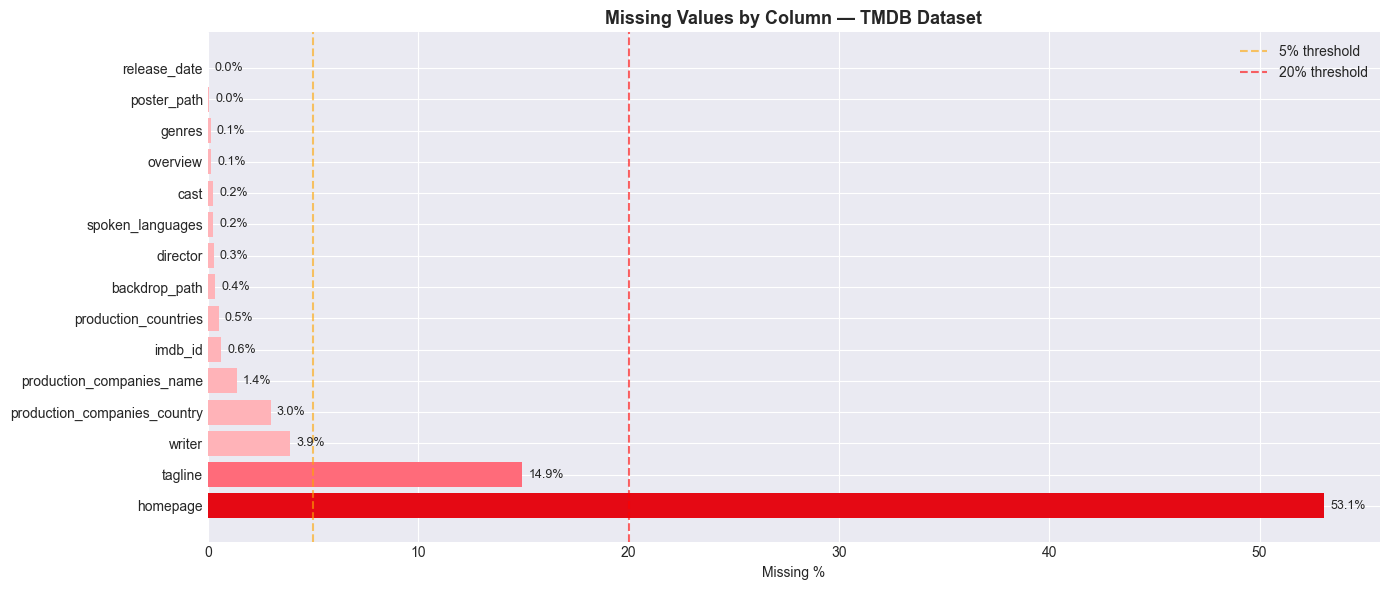

In [ ]:
## Visualise missing values
fig, ax = plt.subplots(figsize=(14, 6))
cols_with_missing = quality_df[quality_df["Missing %"] > 0]
bars = ax.barh(cols_with_missing.index, cols_with_missing["Missing %"],
               color=["#e50914" if x > 20 else "#ff6b7a" if x > 5 else "#ffb3b8"
                      for x in cols_with_missing["Missing %"]])
ax.set_xlabel("Missing %")
ax.set_title("Missing Values by Column — TMDB Dataset", fontsize=13, fontweight="bold")
for bar, val in zip(bars, cols_with_missing["Missing %"]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va="center", fontsize=9)
ax.axvline(5,  color="orange", linestyle="--", alpha=0.6, label="5% threshold")
ax.axvline(20, color="red",    linestyle="--", alpha=0.6, label="20% threshold")
ax.legend()
plt.tight_layout()
plt.savefig("../exports/fig_missing_values.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# duplicate check "id"
# "title", "imdb_id"
print(" DUPLICATE ANALYSIS:")
print(f"  Full row duplicates:   {df_raw.duplicated().sum()}")
print(f"  Duplicate TMDB IDs:    {df_raw.duplicated(subset=['id']).sum()}")
print(f"  Duplicate titles:      {df_raw.duplicated(subset=['title']).sum()}")
print(f"  Duplicate IMDb IDs:    {df_raw.duplicated(subset=['imdb_id']).sum()}")

# Outlier check
print("\n OUTLIER ANALYSIS:")
for col in ["runtime","vote_average","budget","revenue","popularity"]:
    q1 = df_raw[col].quantile(0.25)
    q3 = df_raw[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((df_raw[col] < q1 - 1.5*iqr) | (df_raw[col] > q3 + 1.5*iqr)).sum()
    print(f"  {col:<30}  Q1={q1:.1f}  Q3={q3:.1f}  Outliers={outliers}")


 DUPLICATE ANALYSIS:
  Full row duplicates:   0
  Duplicate TMDB IDs:    0
  Duplicate titles:      142
  Duplicate IMDb IDs:    33

 OUTLIER ANALYSIS:
  runtime                         Q1=94.0  Q3=121.0  Outliers=314
  vote_average                    Q1=6.4  Q3=7.5  Outliers=134
  budget                          Q1=0.0  Q3=35000000.0  Outliers=532
  revenue                         Q1=0.0  Q3=100163395.0  Outliers=569
  popularity                      Q1=4.0  Q3=7.4  Outliers=470


**Duplicates :** The dataset contains no duplicate rows.

**TMDB IDs :**

* `0`: Every movie has a unique identifier, serving as the primary key.

**Titles :**

* `142` movies appear multiple times ("Batman" in 1966, 1989, 2022). These are not duplicates, but remakes/reboots.

**IMDb IDs :**

* `33` movies share the same key for various reasons : movies fetched across multiple endpoints, or errors in the TMDB API >> **Action:** Deduplicate on `imdb_id`, keeping the entry with the highest vote count.

**Outliers :**

**Runtime :**

* Interquartile range (Q3 - Q1 = 31 min) >> 314 movies are very short (< 54 min) or very long (> 161 min, including the 960-min runtime).

**Vote_avg :**

* Interquartile range (Q3 - Q1 = 1.1) >> 134 movies are rated < 4.75 or > 9.15 for recommendation.

**Revenue :**

* 569 movies with revenue > $250M (the blockbusters).

**Popularity :**

* 470 movies with a score > 12.5 (including our maximum of 683) >> skewed distribution > normalize using `MinMaxScaler`.